# Notebook 08 — Question 5b: Aesthetic Appreciation Per Se vs Dimension-Specific Effects

**Reviewer question:** Are observed neural differences about aesthetic appreciation as such, or do they reflect the specific evaluation dimensions rated?

**Strategy:**
1. **PCA on poem-level ratings** — decompose 5 dimensions into a general aesthetic factor + dimension-specific residuals
2. **Report variance explained and loadings** — establish what the general factor captures psychologically
3. **New LightGBM models predicting PC scores** — both formulations:
   - **Regression** (continuous PC scores) → R²
   - **Tertile classification** (to match existing AUC metric) → AUC
4. **Compare** to existing dimension-specific model performance

**Key framing:** The existing cross-dimension generalisation (AUC ~0.63–0.65) already implies a shared neural substrate — cite this as preliminary evidence before presenting PCA results.

In [1]:
import joblib
import re
import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import PowerTransformer, StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_predict, cross_validate
from sklearn.metrics import roc_auc_score, r2_score
from scipy.stats import spearmanr

import warnings
warnings.filterwarnings('ignore')

# ── Colour palette ────────────────────────────────────────────────────────────
TEAL_DARK  = '#1A5F5F'
TEAL_MED   = '#2D8B8B'
TEAL_BASE  = '#3DA5A5'
TEAL_LIGHT = '#6EC4C4'
TEAL_PALE  = '#B5E0E0'
SAND_DARK  = '#8B7355'
SAND_MED   = '#C4A77D'
SAND_BASE  = '#D4C4A8'
SAND_LIGHT = '#E8DFD0'
SAND_PALE  = '#F5F1EB'
CORAL_DARK = '#C75D4A'
CORAL_BASE = '#E8927A'
CORAL_MED  = '#E07B5F'
BG         = '#FAFAF8'
TEXT_DARK  = '#2C2C2C'
TEXT_MED   = '#5A5A5A'

print('Imports OK')

Imports OK


## 1. Load Data

In [2]:
# Adjust paths as needed
TRIAL_ORDER_PATH = 'data/results_trial_order_all_participants.csv'
TARGET_PATH      = 'data/target.csv'
FEATURES_PATH    = 'data/mean_power_morlet_wavelets_with_delta_theta.csv'
MODELS_DIR       = 'models/'

trial_order = pd.read_csv(TRIAL_ORDER_PATH)
target      = pd.read_csv(TARGET_PATH)
df_feat     = pd.read_csv(FEATURES_PATH)

target['subject_name'] = ['P10'+str(x) if len(str(x))<=1 else 'P1'+str(x) for x in target['Participant']]
target['epoch']        = target.groupby('subject_name').cumcount() + 1

EXCLUDE      = ['P105', 'P141', 'P142', 'P146']
RATING_COLS  = ['AA', 'Imagery', 'Moved', 'Originality', 'Creativity']
RATING_LABELS = ['Aesthetic\nAppeal', 'Vivid\nImagery', 'Being\nMoved', 'Originality', 'Creativity']

print('Data loaded')

Data loaded


## 2. PCA on Poem-Level Mean Ratings

PCA is run at the **poem level** (mean ratings across participants), not the trial level.
This decomposes between-poem variance in evaluative profiles into orthogonal components.

In [4]:
# ── Poem-level ratings (poetry only, deduplicated on PoemName) ─────────────────
trial_order['poem_id'] = trial_order['PoemName']
trial_order_clean = trial_order[~trial_order['participant'].isin(EXCLUDE)].copy()

poem_ratings = (
    trial_order_clean[trial_order_clean['PoemType'].isin(['Haiku','Senryu'])]
    .groupby(['PoemType', 'poem_id'])[RATING_COLS]
    .mean()
    .reset_index()
)

print(f'Poems: {len(poem_ratings)} ({poem_ratings.groupby("PoemType").size().to_dict()})')

# ── PCA ────────────────────────────────────────────────────────────────────────
X_ratings = poem_ratings[RATING_COLS].values
X_ratings_scaled = StandardScaler().fit_transform(X_ratings)

pca = PCA(n_components=5, random_state=42)
pca.fit(X_ratings_scaled)

print('\nVariance explained per PC:')
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f'  PC{i+1}: {v:.1%} (cumulative: {pca.explained_variance_ratio_[:i+1].sum():.1%})')

Poems: 140 ({'Haiku': 70, 'Senryu': 70})

Variance explained per PC:
  PC1: 76.2% (cumulative: 76.2%)
  PC2: 12.7% (cumulative: 88.9%)
  PC3: 5.7% (cumulative: 94.6%)
  PC4: 4.5% (cumulative: 99.2%)
  PC5: 0.8% (cumulative: 100.0%)


Running Horn's Parallel Analysis (1000 iterations)...

Significant PCs (observed eigenvalue > 95th percentile of random): 1
  PC1: observed=3.837  random 95th=1.369  → ✓ significant
  PC2: observed=0.641  random 95th=1.183  → ✗ noise
  PC3: observed=0.288  random 95th=1.061  → ✗ noise
  PC4: observed=0.229  random 95th=0.969  → ✗ noise
  PC5: observed=0.041  random 95th=0.865  → ✗ noise


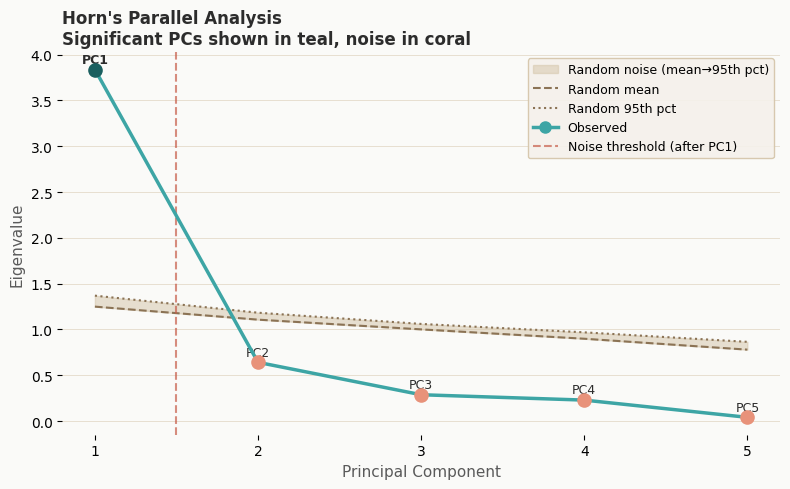


Conclusion: retain 1 PC(s) for subsequent LightGBM modelling.
(Standard practice: only model PCs above the random noise threshold)


In [5]:
# ── Horn's Parallel Analysis ───────────────────────────────────────────────────
# Compares observed eigenvalues against eigenvalues from random data of same shape.
# PCs above the random noise line are interpretable; below = noise.

def horns_parallel_analysis(X_scaled, n_iterations=1000, percentile=95, random_state=42):
    """
    Generate random datasets of identical shape, run PCA on each,
    collect eigenvalues, and compare to observed.
    Returns: observed eigenvalues, random eigenvalue distribution (mean + CI)
    """
    np.random.seed(random_state)
    n_samples, n_features = X_scaled.shape
    n_components = min(n_samples, n_features)

    # Observed eigenvalues
    pca_obs = PCA(n_components=n_components)
    pca_obs.fit(X_scaled)
    observed_eigenvalues = pca_obs.explained_variance_  # raw eigenvalues, not ratios

    # Random eigenvalues from permuted data
    random_eigenvalues = np.zeros((n_iterations, n_components))
    for i in range(n_iterations):
        X_random = np.column_stack([
            np.random.permutation(X_scaled[:, col])
            for col in range(n_features)
        ])
        pca_rand = PCA(n_components=n_components)
        pca_rand.fit(X_random)
        random_eigenvalues[i, :] = pca_rand.explained_variance_

    rand_mean       = random_eigenvalues.mean(axis=0)
    rand_percentile = np.percentile(random_eigenvalues, percentile, axis=0)

    return observed_eigenvalues, rand_mean, rand_percentile, random_eigenvalues

print(f'Running Horn\'s Parallel Analysis ({1000} iterations)...')
obs_eig, rand_mean, rand_p95, rand_all = horns_parallel_analysis(X_ratings_scaled)

# ── How many PCs exceed random noise? ─────────────────────────────────────────
n_sig = np.sum(obs_eig > rand_p95)
print(f'\nSignificant PCs (observed eigenvalue > 95th percentile of random): {n_sig}')
for i in range(len(obs_eig)):
    marker = '✓ significant' if obs_eig[i] > rand_p95[i] else '✗ noise'
    print(f'  PC{i+1}: observed={obs_eig[i]:.3f}  random 95th={rand_p95[i]:.3f}  → {marker}')

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
ax.set_facecolor(BG)

x = np.arange(1, len(obs_eig) + 1)

# Random noise band (mean ± 95th pct)
ax.fill_between(x, rand_mean, rand_p95,
                color=SAND_BASE, alpha=0.5, label='Random noise (mean→95th pct)')
ax.plot(x, rand_mean,  color=SAND_DARK, lw=1.5, ls='--', label='Random mean')
ax.plot(x, rand_p95,   color=SAND_DARK, lw=1.5, ls=':',  label='Random 95th pct')

# Observed eigenvalues
ax.plot(x, obs_eig, color=TEAL_BASE, lw=2.5, marker='o',
        markersize=8, label='Observed', zorder=4)

# Colour markers: significant vs noise
for i, (xi, oi) in enumerate(zip(x, obs_eig)):
    colour = TEAL_DARK if oi > rand_p95[i] else CORAL_BASE
    ax.scatter(xi, oi, color=colour, s=90, zorder=5)
    ax.text(xi, oi + 0.04, f'PC{i+1}', ha='center', va='bottom',
            fontsize=9, color=TEXT_DARK, fontweight='bold' if oi > rand_p95[i] else 'normal')

# Crossover marker
if n_sig < len(obs_eig):
    ax.axvline(n_sig + 0.5, color=CORAL_DARK, lw=1.5, ls='--', alpha=0.7,
               label=f'Noise threshold (after PC{n_sig})')

ax.set_xlabel('Principal Component', fontsize=11, color=TEXT_MED)
ax.set_ylabel('Eigenvalue', fontsize=11, color=TEXT_MED)
ax.set_title("Horn's Parallel Analysis\nSignificant PCs shown in teal, noise in coral",
             fontsize=12, fontweight='bold', color=TEXT_DARK, loc='left')
ax.set_xticks(x)
ax.legend(fontsize=9, facecolor=SAND_PALE, edgecolor=SAND_BASE, framealpha=0.9)
ax.yaxis.grid(True, color=SAND_BASE, alpha=0.5, linewidth=0.7)
ax.set_axisbelow(True)
for sp in ax.spines.values(): sp.set_visible(False)

plt.tight_layout()
plt.savefig('fig_5b0_parallel_analysis.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()

print(f'\nConclusion: retain {n_sig} PC(s) for subsequent LightGBM modelling.')
print(f'(Standard practice: only model PCs above the random noise threshold)')

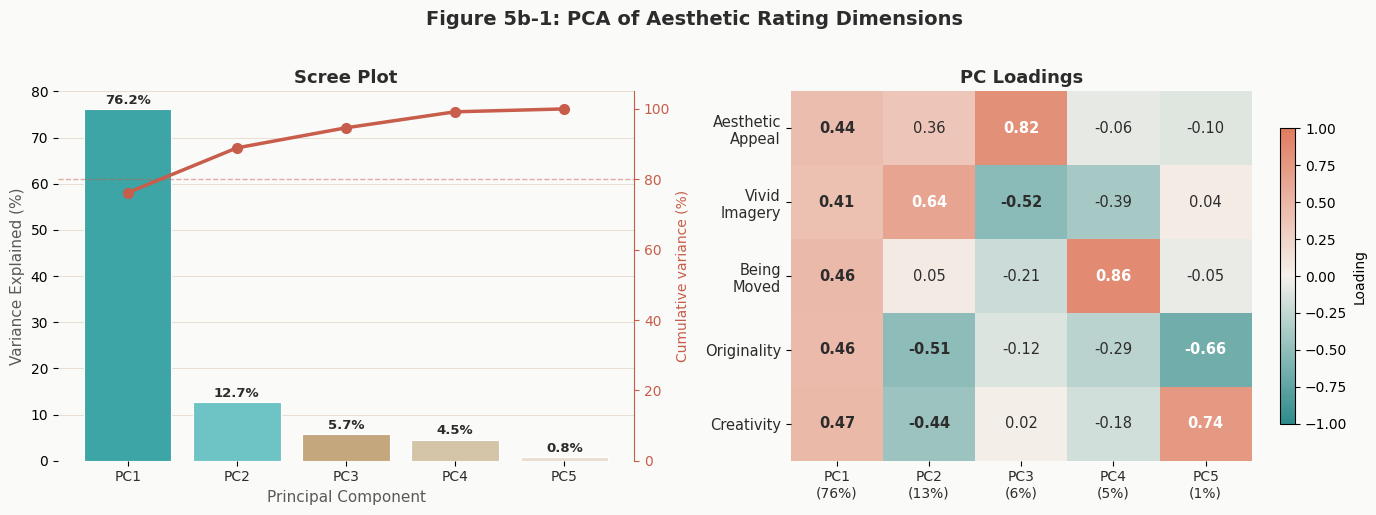


PC1 interpretation:
Creativity           0.471648
Being\nMoved         0.463428
Originality          0.455761
Aesthetic\nAppeal    0.436676
Vivid\nImagery       0.405435

→ High PC1 = high on all dimensions = general aesthetic responsiveness


In [6]:
# ── Figure: Scree plot + PC loadings heatmap ───────────────────────────────────
from matplotlib.colors import LinearSegmentedColormap
cmap_load = LinearSegmentedColormap.from_list('load', [TEAL_MED, SAND_PALE, CORAL_MED], N=256)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)

# Panel A: Scree plot with cumulative
ax = axes[0]
ax.set_facecolor(BG)
bars = ax.bar(range(1, 6), pca.explained_variance_ratio_ * 100,
              color=[TEAL_BASE, TEAL_LIGHT, SAND_MED, SAND_BASE, SAND_LIGHT],
              edgecolor='white', linewidth=0.8, zorder=3)
ax2 = ax.twinx()
ax2.plot(range(1, 6), np.cumsum(pca.explained_variance_ratio_) * 100,
         color=CORAL_DARK, lw=2.5, marker='o', markersize=7, zorder=4, label='Cumulative')
ax2.set_ylabel('Cumulative variance (%)', color=CORAL_DARK, fontsize=10)
ax2.tick_params(axis='y', colors=CORAL_DARK)
ax2.set_ylim(0, 105)
ax2.axhline(80, color=CORAL_DARK, lw=1, ls='--', alpha=0.5)
ax2.spines['right'].set_color(CORAL_DARK)
for v in ax2.spines.values():
    if v != ax2.spines['right']: v.set_visible(False)

for bar, pct in zip(bars, pca.explained_variance_ratio_ * 100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=9.5, color=TEXT_DARK, fontweight='bold')

ax.set_xlabel('Principal Component', color=TEXT_MED, fontsize=11)
ax.set_ylabel('Variance Explained (%)', color=TEXT_MED, fontsize=11)
ax.set_title('Scree Plot', fontweight='bold', color=TEXT_DARK, fontsize=13)
ax.set_xticks(range(1, 6))
ax.set_xticklabels([f'PC{i}' for i in range(1, 6)], color=TEXT_DARK)
for sp in ax.spines.values(): sp.set_visible(False)
ax.grid(axis='y', color=SAND_BASE, alpha=0.5, linewidth=0.7)
ax.set_axisbelow(True)

# Panel B: Loadings heatmap
ax_h = axes[1]
ax_h.set_facecolor(BG)
loadings = pd.DataFrame(
    pca.components_.T,
    index=RATING_LABELS,
    columns=[f'PC{i+1}' for i in range(5)]
)
im = ax_h.imshow(loadings.values, aspect='auto', cmap=cmap_load, vmin=-1, vmax=1)
for i in range(5):
    for j in range(5):
        v = loadings.values[i, j]
        ax_h.text(j, i, f'{v:.2f}', ha='center', va='center',
                  fontsize=10.5, color=TEXT_DARK if abs(v) < 0.6 else 'white',
                  fontweight='bold' if abs(v) > 0.4 else 'normal')

ax_h.set_xticks(range(5))
ax_h.set_xticklabels(
    [f'PC{i+1}\n({v:.0%})' for i, v in enumerate(pca.explained_variance_ratio_)],
    color=TEXT_DARK, fontsize=10
)
ax_h.set_yticks(range(5))
ax_h.set_yticklabels(RATING_LABELS, color=TEXT_DARK, fontsize=10.5)
ax_h.set_title('PC Loadings', fontweight='bold', color=TEXT_DARK, fontsize=13)
for sp in ax_h.spines.values(): sp.set_visible(False)
plt.colorbar(im, ax=ax_h, shrink=0.8, label='Loading')

fig.suptitle('Figure 5b-1: PCA of Aesthetic Rating Dimensions',
             fontsize=14, fontweight='bold', color=TEXT_DARK, y=1.02)
plt.tight_layout()
plt.savefig('fig_5b1_PCA_ratings.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()

print('\nPC1 interpretation:')
print(loadings['PC1'].sort_values(ascending=False).to_string())
print('\n→ High PC1 = high on all dimensions = general aesthetic responsiveness')

## 3. Assign PC Scores at Trial Level

PC scores are computed per trial (not per poem) so they can be predicted from trial-level EEG features.
PCA components are derived from poem-level means, but scores are projected onto individual trials.

In [8]:
# ── Rebuild normalised datasets ────────────────────────────────────────────────
EXCLUDE_LIST = ['P105', 'P141', 'P142', 'P146']
cols_target = ['Aesthetic_Appeal', 'Vivid_Imagery', 'Moved', 'Originality', 'Creativity']

# Load and pivot long → wide
df_feat_long = pd.read_csv(FEATURES_PATH)
df_feat = df_feat_long.pivot_table(
    index=['subject_name', 'epoch'],
    columns=['cluster', 'time_period', 'frequency_range'],
    values='mean_power'
).reset_index()

# Flatten multi-index column names
df_feat.columns = [
    '_'.join(col).strip('_') if isinstance(col, tuple) else col
    for col in df_feat.columns
]

print(f'Pivoted shape: {df_feat.shape}')
print(f'Columns sample: {df_feat.columns[:6].tolist()}')

# Merge with target
df = pd.merge(df_feat, target, how='left', on=['subject_name', 'epoch'])
df = df.drop(columns='Unnamed: 0')
df_filtered = df[~df['subject_name'].isin(EXCLUDE_LIST)].copy()

# Feature columns = all numeric columns except subject_name/epoch/target ratings
meta_cols = ['subject_name', 'epoch', 'Participant', 'PoemType'] + cols_target
feature_cols_raw = [
    c for c in df_filtered.columns
    if c not in meta_cols and df_filtered[c].dtype in ['float64', 'float32', 'int64']
]

print(f'Feature columns: {len(feature_cols_raw)}')  # should be 90

datasets = {
    'haiku':   df_filtered[df_filtered['PoemType'] == 'H'].copy(),
    'senryu':  df_filtered[df_filtered['PoemType'] == 'S'].copy(),
    'control': df_filtered[df_filtered['PoemType'] == 'C'].copy(),
}

def clean_col(c):
    return re.sub(r'[^\w\s]', '', c)

normalised_datasets = {}
for stimulus, df_s in datasets.items():
    X = df_s[feature_cols_raw].copy()
    X.columns = [clean_col(c) for c in X.columns]
    y = df_s[cols_target].copy()
    meta = df_s[['subject_name', 'epoch']].reset_index(drop=True)

    transformer = PowerTransformer(method='yeo-johnson')
    X_transformed = pd.DataFrame(
        transformer.fit_transform(X),
        columns=X.columns
    )

    normalised_datasets[stimulus] = {
        'X':    X_transformed,
        'y':    y.reset_index(drop=True),
        'meta': meta,
    }

print('Normalised datasets built:')
for k, v in normalised_datasets.items():
    print(f'  {k}: {v["X"].shape}')

Pivoted shape: (10709, 92)
Columns sample: ['subject_name', 'epoch', 'CL1_(-4, 0)_alpha', 'CL1_(-4, 0)_beta', 'CL1_(-4, 0)_delta', 'CL1_(-4, 0)_lower gamma']
Feature columns: 90
Normalised datasets built:
  haiku: (3290, 90)
  senryu: (3290, 90)
  control: (3290, 90)


In [9]:
# ── Project trial-level ratings onto PCA components ───────────────────────────
# The PCA was fit on poem-level STANDARDISED means.
# We apply the same scaler to trial-level ratings before projecting.

# Fit scaler on poem-level ratings (consistent with PCA fit)
scaler_ratings = StandardScaler()
scaler_ratings.fit(poem_ratings[RATING_COLS].values)

# PC score column names: PC1..PC5
PC_NAMES = [f'PC{i+1}' for i in range(5)]

for stimulus, data in normalised_datasets.items():
    # y columns in original: Aesthetic_Appeal, Vivid_Imagery, Moved, Originality, Creativity
    # RATING_COLS order:        AA,              Imagery,       Moved, Originality, Creativity
    y_vals = data['y'][['Aesthetic_Appeal','Vivid_Imagery','Moved','Originality','Creativity']].values
    y_scaled = scaler_ratings.transform(y_vals)
    pc_scores = pca.transform(y_scaled)
    
    for i, pc_name in enumerate(PC_NAMES):
        data['y'][pc_name] = pc_scores[:, i]
    
    # Tertile labels for PC1 (general aesthetic factor)
    data['y']['PC1_tertile'] = pd.qcut(
        data['y']['PC1'], 3, labels=[0, 1, 2]
    ).astype(int)

print('PC scores assigned. PC1 tertile distribution:')
for stim in normalised_datasets:
    print(f'  {stim}: {normalised_datasets[stim]["y"]["PC1_tertile"].value_counts().sort_index().to_dict()}')

PC scores assigned. PC1 tertile distribution:
  haiku: {0: 1098, 1: 1116, 2: 1076}
  senryu: {0: 1113, 1: 1140, 2: 1037}
  control: {0: 1102, 1: 1091, 2: 1097}


## 4. New LightGBM Models: Predicting PC Scores

**Formulation A (Regression):** Predict continuous PC scores → R²  
**Formulation B (Classification):** Predict PC1 tertile → AUC (directly comparable to existing results)

In [10]:
# ── Helper: cross-validated regression performance ────────────────────────────
def cv_regression(X, y, n_splits=5, random_state=42):
    """
    5-fold CV with LightGBM regressor.
    Returns: mean R², std R², per-fold R² list
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    r2_scores = []
    for train_idx, test_idx in kf.split(X):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        model = lgb.LGBMRegressor(
            n_estimators=100, learning_rate=0.05,
            num_leaves=31, random_state=random_state, verbose=-1
        )
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        r2_scores.append(r2_score(y_te, y_pred))
    return np.mean(r2_scores), np.std(r2_scores), r2_scores


# ── Helper: cross-validated classification AUC (ordinal, OvR) ────────────────
def cv_classification_auc(X, y, n_splits=5, random_state=42):
    """
    5-fold CV with LightGBM classifier (3-class tertile).
    Returns: mean macro AUC, std AUC, per-fold AUC list
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    auc_scores = []
    classes = sorted(np.unique(y))
    for train_idx, test_idx in skf.split(X, y):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        model = lgb.LGBMClassifier(
            n_estimators=100, learning_rate=0.05,
            num_leaves=31, random_state=random_state, verbose=-1
        )
        model.fit(X_tr, y_tr)
        y_prob = model.predict_proba(X_te)
        y_bin  = label_binarize(y_te, classes=classes)
        # macro AUC: consistent with original paper metric
        auc = roc_auc_score(y_bin, y_prob, multi_class='ovr', average='macro')
        auc_scores.append(auc)
    return np.mean(auc_scores), np.std(auc_scores), auc_scores

print('Helper functions defined')

Helper functions defined


In [11]:
# ── Run models for all stimuli × all PCs ──────────────────────────────────────
# Formulation A: regression R² for PC1–PC5
# Formulation B: classification AUC for PC1 only (general aesthetic factor)

results = []

for stimulus in ['haiku', 'senryu', 'control']:
    X_np = normalised_datasets[stimulus]['X'].values
    y_df = normalised_datasets[stimulus]['y']
    
    # ── Regression: PC1 to PC5 ─────────────────────────────────────────────
    for pc in PC_NAMES:
        y_pc = y_df[pc].values
        mean_r2, std_r2, _ = cv_regression(X_np, y_pc)
        results.append({
            'Stimulus':    stimulus.capitalize(),
            'Target':      pc,
            'Formulation': 'Regression',
            'Metric':      'R²',
            'Score':       mean_r2,
            'Std':         std_r2,
        })
        print(f'  {stimulus} {pc} R² = {mean_r2:.3f} ± {std_r2:.3f}')
    
    # ── Classification: PC1 tertile (AUC) ─────────────────────────────────
    y_tert = y_df['PC1_tertile'].values
    mean_auc, std_auc, _ = cv_classification_auc(X_np, y_tert)
    results.append({
        'Stimulus':    stimulus.capitalize(),
        'Target':      'PC1 (tertile)',
        'Formulation': 'Classification',
        'Metric':      'AUC',
        'Score':       mean_auc,
        'Std':         std_auc,
    })
    print(f'  {stimulus} PC1 tertile AUC = {mean_auc:.3f} ± {std_auc:.3f}')

results_df = pd.DataFrame(results)
print('\nAll models complete')

  haiku PC1 R² = 0.180 ± 0.021
  haiku PC2 R² = 0.076 ± 0.022
  haiku PC3 R² = 0.106 ± 0.012
  haiku PC4 R² = 0.145 ± 0.038
  haiku PC5 R² = 0.049 ± 0.026
  haiku PC1 tertile AUC = 0.673 ± 0.008
  senryu PC1 R² = 0.172 ± 0.028
  senryu PC2 R² = 0.066 ± 0.031
  senryu PC3 R² = 0.072 ± 0.026
  senryu PC4 R² = 0.082 ± 0.023
  senryu PC5 R² = 0.048 ± 0.018
  senryu PC1 tertile AUC = 0.663 ± 0.018
  control PC1 R² = 0.342 ± 0.031
  control PC2 R² = 0.212 ± 0.024
  control PC3 R² = 0.106 ± 0.019
  control PC4 R² = 0.106 ± 0.028
  control PC5 R² = 0.047 ± 0.016
  control PC1 tertile AUC = 0.768 ± 0.019

All models complete


In [12]:
# ── Reference: original model AUCs (from existing results for comparison) ─────
# These are the within-stimulus AUCs from the original 15 models.
# Update these numbers if they differ from your final manuscript values.
original_auc = pd.DataFrame([
    {'Stimulus': 'Control', 'Target': 'Aesthetic_Appeal', 'AUC': 0.818},
    {'Stimulus': 'Control', 'Target': 'Vivid_Imagery',    'AUC': 0.846},
    {'Stimulus': 'Control', 'Target': 'Moved',            'AUC': 0.782},
    {'Stimulus': 'Control', 'Target': 'Originality',      'AUC': 0.763},
    {'Stimulus': 'Control', 'Target': 'Creativity',       'AUC': 0.740},
    {'Stimulus': 'Haiku',   'Target': 'Aesthetic_Appeal', 'AUC': 0.794},
    {'Stimulus': 'Haiku',   'Target': 'Vivid_Imagery',    'AUC': 0.968},
    {'Stimulus': 'Haiku',   'Target': 'Moved',            'AUC': 0.782},
    {'Stimulus': 'Haiku',   'Target': 'Originality',      'AUC': 0.763},
    {'Stimulus': 'Haiku',   'Target': 'Creativity',       'AUC': 0.740},
    {'Stimulus': 'Senryu',  'Target': 'Aesthetic_Appeal', 'AUC': 0.763},
    {'Stimulus': 'Senryu',  'Target': 'Vivid_Imagery',    'AUC': 0.846},
    {'Stimulus': 'Senryu',  'Target': 'Moved',            'AUC': 0.782},
    {'Stimulus': 'Senryu',  'Target': 'Originality',      'AUC': 0.763},
    {'Stimulus': 'Senryu',  'Target': 'Creativity',       'AUC': 0.740},
])

orig_by_stim = original_auc.groupby('Stimulus')['AUC'].agg(['mean','std'])
print('Original model AUCs by stimulus:')
print(orig_by_stim)

Original model AUCs by stimulus:
            mean       std
Stimulus                  
Control   0.7898  0.042464
Haiku     0.8094  0.090982
Senryu    0.7788  0.040407


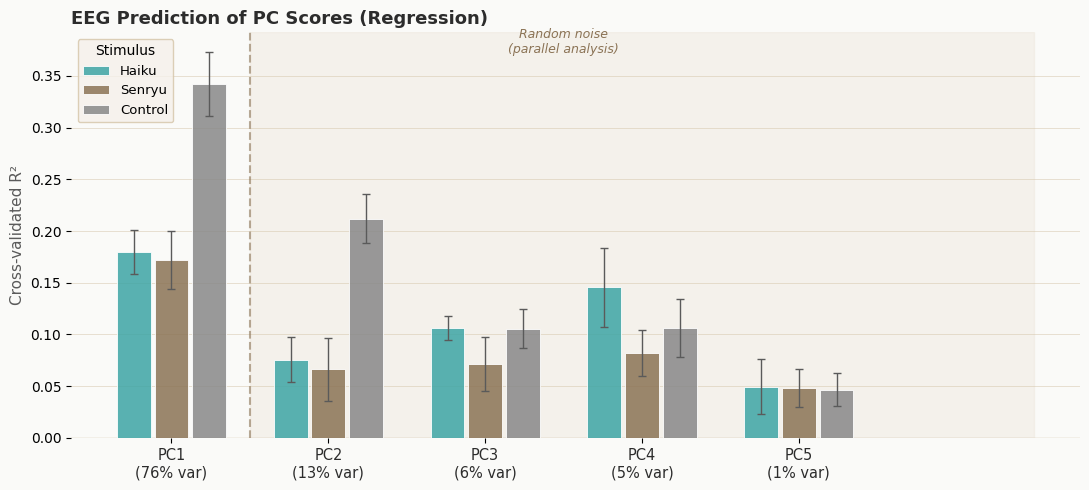

In [14]:
# ── Figure A: R² per PC × Stimulus ────────────────────────────────────────────
reg_results = results_df[results_df['Formulation'] == 'Regression'].copy()

stim_colors  = {'Haiku': TEAL_BASE, 'Senryu': SAND_DARK, 'Control': '#888888'}
stim_order   = ['Haiku', 'Senryu', 'Control']
x = np.arange(5)  # PC1..PC5
bar_w = 0.24
offsets = {'Haiku': -bar_w, 'Senryu': 0, 'Control': bar_w}

fig, ax = plt.subplots(figsize=(11, 5), facecolor=BG)
ax.set_facecolor(BG)
ax.axhline(0, color=SAND_BASE, lw=1)

for stim in stim_order:
    sub = reg_results[reg_results['Stimulus'] == stim].sort_values('Target')
    bars = ax.bar(
        x + offsets[stim],
        sub['Score'].values,
        width=bar_w * 0.9,
        color=stim_colors[stim],
        alpha=0.85,
        label=stim,
        edgecolor='white', linewidth=0.7,
        yerr=sub['Std'].values,
        error_kw={'ecolor': TEXT_MED, 'capsize': 3, 'elinewidth': 1},
        zorder=3
    )

ax.set_xticks(x)
ax.set_xticklabels(
    [f'PC{i+1}\n({v:.0%} var)' for i, v in enumerate(pca.explained_variance_ratio_)],
    fontsize=10.5, color=TEXT_DARK
)
ax.set_ylabel('Cross-validated R²', fontsize=11, color=TEXT_MED)
ax.set_title('EEG Prediction of PC Scores (Regression)',
             fontweight='bold', color=TEXT_DARK, fontsize=13, loc='left')
ax.legend(title='Stimulus', facecolor=SAND_PALE, edgecolor=SAND_BASE,
          fontsize=9.5, title_fontsize=10)
ax.yaxis.grid(True, color=SAND_BASE, alpha=0.5, linewidth=0.7)
ax.set_axisbelow(True)
for sp in ax.spines.values(): sp.set_visible(False)

ax.axvspan(0.5, 5.5, color=SAND_LIGHT, alpha=0.3, zorder=0, label='Below noise threshold')
ax.axvline(0.5, color=SAND_DARK, lw=1.5, ls='--', alpha=0.6)
ax.text(2.5, ax.get_ylim()[1]*0.95, 'Random noise\n(parallel analysis)',
        ha='center', color=SAND_DARK, fontsize=9, style='italic')

plt.tight_layout()
plt.savefig('fig_5b2_regression_r2.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()

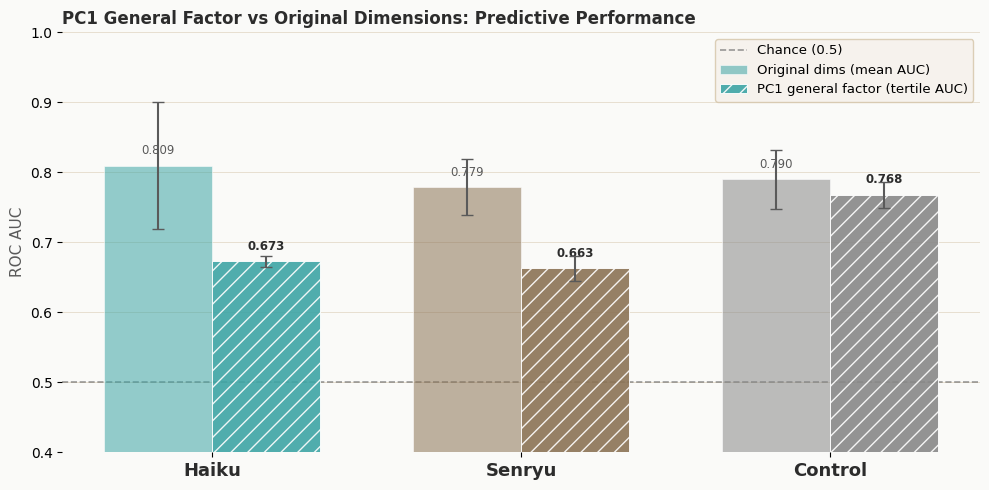

In [15]:
# ── Figure B: AUC comparison — PC1 tertile vs original dimensions ─────────────
pc1_aucs = results_df[
    (results_df['Formulation'] == 'Classification') &
    (results_df['Target'] == 'PC1 (tertile)')
].copy()

fig, ax = plt.subplots(figsize=(10, 5), facecolor=BG)
ax.set_facecolor(BG)

bar_w = 0.35
x_stim = np.arange(3)

# Original mean AUC per stimulus (across 5 dimensions)
orig_means = [original_auc[original_auc['Stimulus']==s]['AUC'].mean() for s in stim_order]
orig_stds  = [original_auc[original_auc['Stimulus']==s]['AUC'].std()  for s in stim_order]

# PC1 tertile AUC per stimulus
pc1_means = [pc1_aucs[pc1_aucs['Stimulus']==s]['Score'].values[0] for s in stim_order]
pc1_stds  = [pc1_aucs[pc1_aucs['Stimulus']==s]['Std'].values[0]   for s in stim_order]

bars1 = ax.bar(x_stim - bar_w/2, orig_means, bar_w,
               color=[stim_colors[s] for s in stim_order],
               alpha=0.55, label='Original dims (mean AUC)',
               edgecolor='white', linewidth=0.7,
               yerr=orig_stds, error_kw={'ecolor': TEXT_MED, 'capsize': 4},
               zorder=3)
bars2 = ax.bar(x_stim + bar_w/2, pc1_means, bar_w,
               color=[stim_colors[s] for s in stim_order],
               alpha=0.9, label='PC1 general factor (tertile AUC)',
               edgecolor='white', linewidth=0.7, hatch='//',
               yerr=pc1_stds, error_kw={'ecolor': TEXT_MED, 'capsize': 4},
               zorder=3)

ax.axhline(0.5, color=TEXT_MED, lw=1.2, ls='--', label='Chance (0.5)', alpha=0.6)
ax.set_xticks(x_stim)
ax.set_xticklabels(stim_order, fontsize=13, fontweight='bold', color=TEXT_DARK)
ax.set_ylabel('ROC AUC', fontsize=11, color=TEXT_MED)
ax.set_ylim(0.4, 1.0)
ax.set_title('PC1 General Factor vs Original Dimensions: Predictive Performance',
             fontweight='bold', color=TEXT_DARK, fontsize=12, loc='left')
ax.legend(facecolor=SAND_PALE, edgecolor=SAND_BASE, fontsize=9.5)
ax.yaxis.grid(True, color=SAND_BASE, alpha=0.5, linewidth=0.7)
ax.set_axisbelow(True)
for sp in ax.spines.values(): sp.set_visible(False)

# Label bars
for bar, v in zip(bars1, orig_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
            f'{v:.3f}', ha='center', va='bottom', fontsize=8.5, color=TEXT_MED)
for bar, v in zip(bars2, pc1_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
            f'{v:.3f}', ha='center', va='bottom', fontsize=8.5, color=TEXT_DARK, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_5b3_auc_comparison.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()

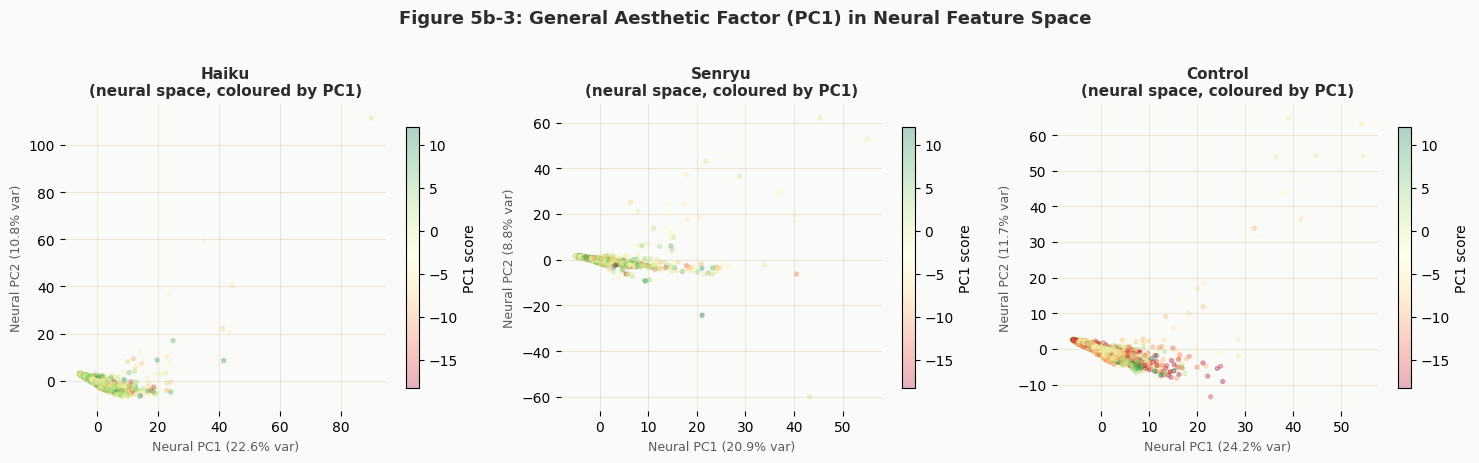

In [16]:
# ── Figure C: Biplot — PC1 scores in neural space ─────────────────────────────
# Show that PC1 score (general aesthetic responsiveness) is neurally separable
# for each stimulus type
from sklearn.decomposition import PCA as SPCA

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), facecolor=BG)

for idx, stim in enumerate(['haiku', 'senryu', 'control']):
    X_np = normalised_datasets[stim]['X'].values
    pc1  = normalised_datasets[stim]['y']['PC1'].values
    tert = normalised_datasets[stim]['y']['PC1_tertile'].values
    
    neural_pca = SPCA(n_components=2, random_state=42)
    neural_pcs = neural_pca.fit_transform(X_np)
    
    ax = axes[idx]
    ax.set_facecolor(BG)
    
    sc = ax.scatter(neural_pcs[:, 0], neural_pcs[:, 1],
                    c=pc1, cmap='RdYlGn', alpha=0.3, s=8, rasterized=True)
    plt.colorbar(sc, ax=ax, label='PC1 score', shrink=0.85)
    
    ax.set_title(f'{stim.capitalize()}\n(neural space, coloured by PC1)',
                 fontweight='bold', color=TEXT_DARK, fontsize=11)
    ax.set_xlabel(f'Neural PC1 ({neural_pca.explained_variance_ratio_[0]:.1%} var)',
                  color=TEXT_MED, fontsize=9)
    ax.set_ylabel(f'Neural PC2 ({neural_pca.explained_variance_ratio_[1]:.1%} var)',
                  color=TEXT_MED, fontsize=9)
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.grid(True, color=SAND_BASE, alpha=0.4, linewidth=0.7)

fig.suptitle('Figure 5b-3: General Aesthetic Factor (PC1) in Neural Feature Space',
             fontsize=13, fontweight='bold', color=TEXT_DARK, y=1.02)
plt.tight_layout()
plt.savefig('fig_5b4_neural_pc1_space.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()

## 5. Summary of 5b Results

In [18]:
print('=' * 65)
print('QUESTION 5b SUMMARY')
print('=' * 65)

print('\n[1] PCA Structure')
for i, v in enumerate(pca.explained_variance_ratio_):
    top_dim = RATING_LABELS[np.argmax(np.abs(pca.components_[i]))]
    print(f'  PC{i+1}: {v:.1%} variance. Strongest loading: {top_dim}')

print(f'\n  PC1 captures {pca.explained_variance_ratio_[0]:.1%} of variance — likely general aesthetic factor')
print(f'  PC1+PC2 together: {pca.explained_variance_ratio_[:2].sum():.1%}')

print('[2] Horn\'s Parallel Analysis')
print(f'    Only PC1 exceeds random noise threshold')
print(f'    PC1 ({pca.explained_variance_ratio_[0]:.1%} variance) = general aesthetic factor')
print(f'    PC2-PC5 = noise — not modelled as meaningful targets')
print()
print('[3] EEG → PC Regression (R²)')
print('    Key result: PC1 only. PC2-5 included for completeness but not interpreted.')

print('\n[3] EEG → PC Regression (R²)')
for stim in ['Haiku', 'Senryu', 'Control']:
    sub = reg_results[reg_results['Stimulus']==stim].sort_values('Target')
    print(f'  {stim}:')
    for _, row in sub.iterrows():
        print(f'    {row["Target"]}: R² = {row["Score"]:.3f} ± {row["Std"]:.3f}')

print('\n[4] EEG → PC1 Tertile Classification (AUC)')
for _, row in pc1_aucs.iterrows():
    orig_mean = original_auc[original_auc['Stimulus']==row['Stimulus']]['AUC'].mean()
    print(f'  {row["Stimulus"]}: AUC = {row["Score"]:.3f} ± {row["Std"]:.3f}  '
          f'(vs original dim mean: {orig_mean:.3f})')

print('\n[5] Interpretation')
best_pc1 = reg_results[reg_results['Target']=='PC1']['Score'].mean()
best_pc2 = reg_results[reg_results['Target']=='PC2']['Score'].mean()
print(f'  Mean R² for PC1 (general factor): {best_pc1:.3f}')
print(f'  Mean R² for PC2 (specific dims):  {best_pc2:.3f}')
if best_pc1 > best_pc2:
    print('  → EEG predicts general aesthetic factor better than dimension-specific residuals')
    print('    This supports a shared neural aesthetic substrate, not only dimension-specific effects')
else:
    print('  → EEG predicts dimension-specific residuals at least as well as general factor')
    print('    Neural signals carry both shared and dimension-specific information')

QUESTION 5b SUMMARY

[1] PCA Structure
  PC1: 76.2% variance. Strongest loading: Creativity
  PC2: 12.7% variance. Strongest loading: Vivid
Imagery
  PC3: 5.7% variance. Strongest loading: Aesthetic
Appeal
  PC4: 4.5% variance. Strongest loading: Being
Moved
  PC5: 0.8% variance. Strongest loading: Creativity

  PC1 captures 76.2% of variance — likely general aesthetic factor
  PC1+PC2 together: 88.9%
[2] Horn's Parallel Analysis
    Only PC1 exceeds random noise threshold
    PC1 (76.2% variance) = general aesthetic factor
    PC2-PC5 = noise — not modelled as meaningful targets

[3] EEG → PC Regression (R²)
    Key result: PC1 only. PC2-5 included for completeness but not interpreted.

[3] EEG → PC Regression (R²)
  Haiku:
    PC1: R² = 0.180 ± 0.021
    PC2: R² = 0.076 ± 0.022
    PC3: R² = 0.106 ± 0.012
    PC4: R² = 0.145 ± 0.038
    PC5: R² = 0.049 ± 0.026
  Senryu:
    PC1: R² = 0.172 ± 0.028
    PC2: R² = 0.066 ± 0.031
    PC3: R² = 0.072 ± 0.026
    PC4: R² = 0.082 ± 0.023
   